In [63]:
#==================================================
# Task 2: Predict Future Stock Prices (Short-Term)
#==================================================

In [64]:

!pip install yfinance

In [65]:
#=====================================================
# 1. Load historical data using the yfinance library
#=====================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler




df = yf.download("AAPL", start="2020-01-01", end="2026-04-26")
df.head()


/tmp/ipykernel_7079/1399347840.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2026-04-26")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
2020-01-07,71.928032,72.533072,71.708672,72.277555,108872000
2020-01-08,73.085091,73.386408,71.631537,71.631537,132079200


In [66]:

# check null values
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
# flatten because multicol

df.columns = df.columns.get_level_values(0)

In [69]:
#===================================================================================
# 3. Use features like Open, High, Low, and Volume to predict the next Close price
#===================================================================================


# Create features and target
X = df[['Open','High','Low','Volume']]
y = df['Close'].shift(-1)  # next day close

# Combine into one DataFrame to drop NaNs together
data= X.copy()
data['Target'] = y

# Drop any row with NaN (usually last row due to shift)
data.dropna(inplace=True)

# Separate features and target again
X = data[['Open','High','Low','Volume']]
y = data['Target']


# split into train and test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, shuffle=False)


# FEATURE SCALING (IMPORTANT)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [70]:
#================================
# 4. Train a Linear Regression
#================================


# load model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


# prediction
lr_pred = lr_model.predict(X_test)

# Mse
print("Linear Regression MSE:", mean_squared_error(y_test, lr_pred))






Linear Regression MSE: 21.326973080184516


In [71]:
# ===========================
# 5. UNSEEN DATA (NEXT DAY)
# ===========================

# take latest available row (most recent day)
latest = df.iloc[-1]

# create input in same feature order
latest_data = [[
    latest['Open'],
    latest['High'],
    latest['Low'],
    latest['Volume']
]]

# apply SAME scaling (VERY IMPORTANT)
latest_data_scaled = scaler.transform(latest_data)

# prediction
next_day_pred = lr_model.predict(latest_data_scaled)

print("Next Day Predicted Close:", next_day_pred[0])

Next Day Predicted Close: 270.38189278634394


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


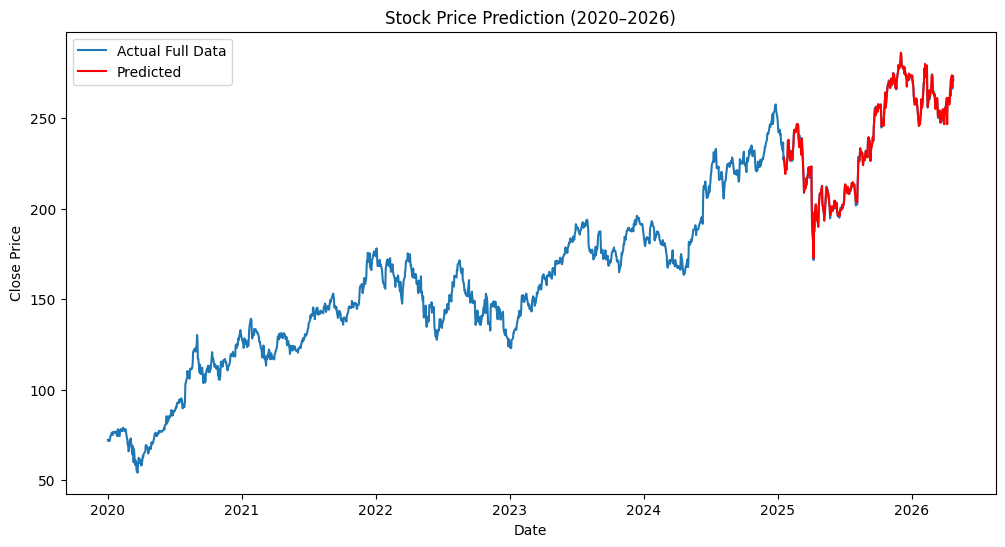

In [72]:
#===========================================================
# 5. Plot actual vs predicted closing prices for comparison
#===========================================================


plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='Actual Full Data')
plt.plot(y_test.index, lr_pred, label='Predicted',color='red')

plt.title("Stock Price Prediction (2020–2026)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [73]:
#=====================
# Random Forest Model
#=====================

In [74]:
#=====================================================
# 1. Load historical data using the yfinance library
#=====================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler




df = yf.download("AAPL", start="2020-01-01", end="2026-04-26")
df.head()


/tmp/ipykernel_7079/1399347840.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2026-04-26")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
2020-01-07,71.928032,72.533072,71.708672,72.277555,108872000
2020-01-08,73.085091,73.386408,71.631537,71.631537,132079200


In [75]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [76]:
# flatten because multicol

df.columns = df.columns.get_level_values(0)

In [77]:
#==================================================================================
# 3. Use features like Open, High, Low, and Volume to predict the next Close price
#==================================================================================


# Create features and target
X = df[['Open','High','Low','Volume']]
y = df['Close'].shift(-1)  # next day close

# Combine into one DataFrame to drop NaNs together
data= X.copy()
data['Target'] = y

# Drop any row with NaN (usually last row due to shift)
data.dropna(inplace=True)

# Separate features and target again
X = data[['Open','High','Low','Volume']]
y = data['Target']



# split into train and test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, shuffle=False)

In [78]:
#===========================
# 4. Train a Random Forest
#===========================


# load model
rf_model = RandomForestRegressor(
    n_estimators=500,
)
rf_model.fit(X_train, y_train)



# prediction
rf_pred = rf_model.predict(X_test)



# Mse
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))

Random Forest MSE: 109.43680165799343


In [79]:
# ===========================
# UNSEEN DATA (NEXT DAY)
# ===========================
latest = df.iloc[-1]

latest_data = [[
    latest['Open'],
    latest['High'],
    latest['Low'],
    latest['Volume']
]]

next_day_pred = rf_model.predict(latest_data)

print("Next Day Predicted Close:", next_day_pred[0])

Next Day Predicted Close: 254.1427160644531


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


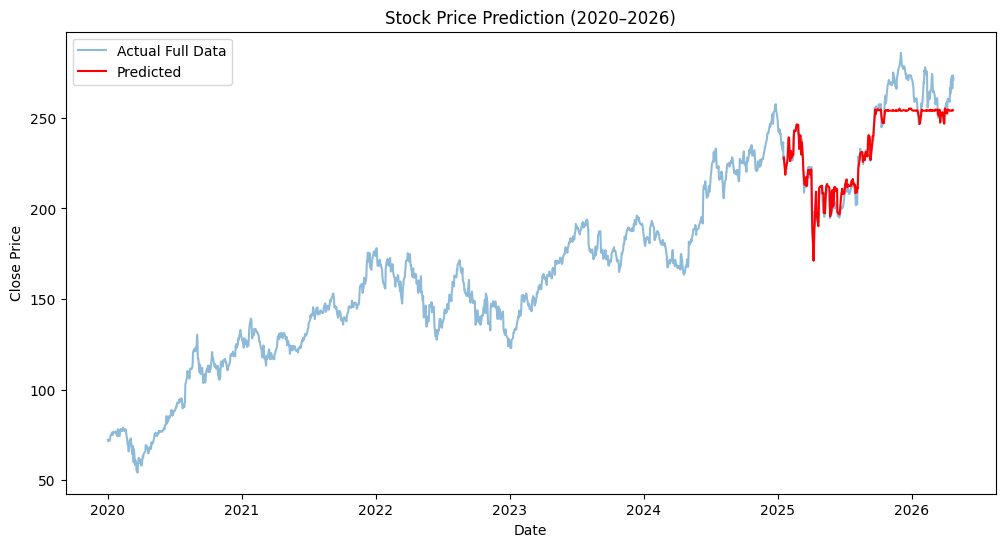

In [80]:
#===========================================================
# 5. Plot actual vs predicted closing prices for comparison
#===========================================================


plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='Actual Full Data',alpha=0.5)
plt.plot(y_test.index, rf_pred, label='Predicted',color='red')

plt.title("Stock Price Prediction (2020–2026)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()